# How the FALCON spreadsheet is measured

1. **What is in FALCON?** The public DANDI download: which files, which splits, what sits inside them.
2. **From that, how do we get the spreadsheet numbers?** Trials, channels, length, raw size, benchmark size.


## 1. What is in FALCON

- Five tasks: H1 (human reach), H2 (human handwriting), M1 (two macaques, reach/grasp + EMG), M2 (macaque fingers), B1 (zebra finch song).
- Each NWB: **unsorted threshold crossings** + a behavior target. Not sorted neurons.
- Splits are in **time**, not extra subjects. DANDI folders like `sub-HumanPitt-held-in-calib` are split labels.

**Which folders we open**

- `held-in-calib` — earlier days, fully labeled (FALCON trains here). **Yes.**
- `held-out-calib` — later days, small labeled slice (FALCON few-shot calibrates here). **Yes.**
- `held-in-minival` — second copy of held-in, for local scoring. **No** (same sessions as held-in).
- Held-out *eval* labels stay on the FALCON leaderboard. Not in this download.

Inventory = unique public labeled files: `held-in-calib` **+** `held-out-calib`. Not “train-only.”

**Keep vs ditch**

- **Keep:** threshold crossings, trial tables, behavior (kinematics / EMG / spectrograms), tiny NWB schema.
- **Ditch:** only M2’s 30 kHz raw voltage (`acquisition/fullband`, ~16 GB). Not a benchmark feature.
- **B1 `tx`:** also 30 kHz, but that *is* the threshold-crossing raster — keep it. Could compress a lot later; that is not this column.


## Get the data

Public FALCON NWBs go in `data/falcon/<dataset>/<dandiset-id>/sub-*/`. DANDI already writes that tree if each dandiset is downloaded into the matching folder.

From the repo root (`dandi` is a LaDyS dependency):

```bash
pip install -e ".[benchmarks]"
bash data/download_falcon.sh
```

Same thing, one command per dataset:

```bash
dandi download DANDI:000954 -o data/falcon/H1     # human reach/grasp
dandi download DANDI:000950 -o data/falcon/H2     # human handwriting
dandi download DANDI:000941 -o data/falcon/M1-A   # monkey L
dandi download DANDI:001209 -o data/falcon/M1-B   # monkey X
dandi download DANDI:000953 -o data/falcon/M2     # monkey N fingers (~16 GB)
dandi download DANDI:001046 -o data/falcon/B1     # zebra finch song
```

About **19 GB** total. `held-in-minival` is a duplicate of held-in; the notebook lists it then ignores it. `*.nwb` is gitignored.

If the files already exist: `ln -s /path/to/falcon data/falcon`. Details: `data/falcon/README.md`.


## 2. How those files become spreadsheet numbers

`inspect_file` applies this to one NWB. Each dataset section names the exact fields.

- **SUBJECTS** — biological animals, not DANDI folders.
- **TRIALS** — count per file, then add (IDs restart).
- **CHANNELS** — unsorted TCs. Median = simultaneous. Total = median except M1 (64+64) and B1 (85×6).
- **NEURONS** — always `N/A`.
- **LENGTH** — sum of usable neural time, not calendar span.
- **RAW** — sum of calib NWB file sizes (the download).
- **BENCHMARK** — compressed HDF5 bytes allocated to retained datasets, excluding embedded NWB schemas and container overhead; M2 also excludes `acquisition/fullband`. This measures the arrays we would host, not Python RAM.
- **BASIC STATS** — channel-session event-rate histograms below (no channel-average for B1).


In [1]:
from __future__ import annotations

from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

here = Path.cwd().resolve()
REPO = here
for candidate in [here, *here.parents]:
    if (candidate / "src" / "ladys").is_dir() or (candidate / "data" / "falcon").exists():
        REPO = candidate
        break
ROOT = REPO / "data" / "falcon"
assert ROOT.exists(), (
    f"Expected FALCON NWBs at {ROOT}. From the repo root run: bash data/download_falcon.sh"
)

DATASETS = ("H1", "H2", "M1-A", "M1-B", "M2", "B1")
SPLITS = ("held-in-calib", "held-in-minival", "held-out-calib")
GB = 1e9


def as_text(value) -> str:
    raw = value[()] if hasattr(value, "__getitem__") and not isinstance(value, (bytes, str)) else value
    if isinstance(raw, bytes):
        return raw.decode()
    return str(raw)


def split_of(path: Path) -> str:
    posix = path.as_posix()
    for split in SPLITS:
        if split in posix:
            return split
    raise ValueError(f"Unrecognized split in {path}")


def calib_paths(dataset: str) -> list[Path]:
    return [p for p in sorted((ROOT / dataset).rglob("*.nwb")) if split_of(p) != "held-in-minival"]


def median_dt(timestamps: h5py.Dataset) -> float:
    sample = np.asarray(timestamps[: min(len(timestamps), 2001)])
    diffs = np.diff(sample)
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    return float(np.median(diffs))


def channel_count(f: h5py.File) -> int:
    if "units/id" in f:
        return len(f["units/id"])
    if "acquisition/binned_spikes/data" in f:
        return int(f["acquisition/binned_spikes/data"].shape[1])
    if "acquisition/tx/data" in f:
        return int(f["acquisition/tx/data"].shape[1])
    raise KeyError("No channel source")


def trial_count(f: h5py.File) -> int:
    if "acquisition/TrialNum/data" in f:
        values = np.asarray(f["acquisition/TrialNum/data"])
        values = values[np.isfinite(values) & (values >= 0)]
        return int(len(np.unique(values)))
    if "intervals/trials/id" in f:
        return int(len(f["intervals/trials/id"]))
    return 0


def recording_seconds(f: h5py.File) -> float:
    if "acquisition/OpenLoopKinematics/data" in f:
        return float(len(f["acquisition/OpenLoopKinematics/data"]) * 0.02)
    if "acquisition/binned_spikes/data" in f:
        return float(len(f["acquisition/binned_spikes/data"]) * 0.02)
    if "acquisition/tx/data" in f:
        return float(len(f["acquisition/tx/data"]) * median_dt(f["acquisition/tx/timestamps"]))
    if "units/obs_intervals" in f:
        intervals = np.asarray(f["units/obs_intervals"])
        return float(np.nanmax(intervals[:, 1]) - np.nanmin(intervals[:, 0]))
    raise KeyError("No duration source")


def stored_bytes(f: h5py.File, skip_prefixes: tuple[str, ...] = ()) -> int:
    """Compressed on-disk bytes allocated to retained HDF5 datasets."""
    total = 0

    def add(name: str, obj: h5py.Group | h5py.Dataset) -> None:
        nonlocal total
        if not isinstance(obj, h5py.Dataset):
            return
        if name.startswith("specifications/"):
            return
        if any(name.startswith(prefix) for prefix in skip_prefixes):
            return
        total += obj.id.get_storage_size()

    f.visititems(add)
    return total


def prefix_bytes(f: h5py.File, prefix: str) -> int:
    """HDF5 on-disk allocated bytes under one path prefix."""
    total = 0

    def add(name: str, obj: h5py.Group | h5py.Dataset) -> None:
        nonlocal total
        if isinstance(obj, h5py.Dataset) and name.startswith(prefix):
            total += obj.id.get_storage_size()

    f.visititems(add)
    return total


def inspect_file(dataset: str, path: Path) -> dict[str, object]:
    file_bytes = path.stat().st_size
    with h5py.File(path, "r") as f:
        return {
            "dataset": dataset,
            "file": path.name,
            "split": split_of(path),
            "channels": channel_count(f),
            "trials": trial_count(f),
            "seconds": recording_seconds(f),
            "file_bytes": file_bytes,
            "benchmark_bytes": stored_bytes(f, skip_prefixes=("acquisition/fullband/",)),
        }


def inspect_dataset(dataset: str) -> pd.DataFrame:
    return pd.DataFrame([inspect_file(dataset, path) for path in calib_paths(dataset)])


def split_breakdown(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.groupby("split", sort=False)
        .agg(files=("file", "size"), trials=("trials", "sum"), minutes=("seconds", lambda s: s.sum() / 60))
        .reset_index()
    )


print("ROOT", ROOT)

RASTER_SECONDS = 2.0
FIGURE_DIR = REPO / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def indexed_vectors(values: np.ndarray, stop_indices: np.ndarray) -> list[np.ndarray]:
    starts = np.r_[0, stop_indices[:-1]]
    return [values[start:stop] for start, stop in zip(starts, stop_indices)]


def units_spikes_by_channel(f: h5py.File) -> list[np.ndarray]:
    return indexed_vectors(
        np.asarray(f["units/spike_times"]),
        np.asarray(f["units/spike_times_index"], dtype=np.int64),
    )


def neural_bin_count(f: h5py.File) -> int | None:
    if "acquisition/OpenLoopKinematics/data" in f:
        return int(len(f["acquisition/OpenLoopKinematics/data"]))
    if "acquisition/binned_spikes/data" in f:
        return int(len(f["acquisition/binned_spikes/data"]))
    if "acquisition/tx/data" in f:
        return int(len(f["acquisition/tx/data"]))
    return None


def channel_event_counts(f: h5py.File, duration: float) -> np.ndarray:
    if "units/spike_times" in f:
        # These NWBs store threshold-crossing event times. H1 includes the
        # first bin at [-20, 0) ms, so counting the complete ragged vectors is
        # both simpler and consistent with the official FALCON binning code.
        return np.asarray([len(times) for times in units_spikes_by_channel(f)])
    if "acquisition/binned_spikes/data" in f:
        return np.asarray(f["acquisition/binned_spikes/data"]).sum(axis=0)
    if "acquisition/tx/data" in f:
        dset = f["acquisition/tx/data"]
        counts = np.zeros(dset.shape[1], dtype=np.int64)
        step = 100_000
        for start in range(0, dset.shape[0], step):
            block = np.asarray(dset[start : start + step])
            if not np.all((block == 0) | (block == 1)):
                raise ValueError("B1 tx contains values other than binary events")
            counts += block.sum(axis=0, dtype=np.int64)
        return counts
    raise KeyError("No spike source")


def raster_spikes_for_file(path: Path, window: float = RASTER_SECONDS) -> list[np.ndarray]:
    with h5py.File(path, "r") as f:
        if "units/spike_times" in f:
            spikes = units_spikes_by_channel(f)
            t0 = 0.0
            if "acquisition/OpenLoopKinematics/starting_time" in f:
                # The official loader treats the acquisition timestamps as
                # bin ends, so the first 20 ms neural bin starts at -0.02 s.
                t0 = float(f["acquisition/OpenLoopKinematics/starting_time"][()]) - 0.02
            elif "units/obs_intervals" in f:
                t0 = float(np.nanmin(np.asarray(f["units/obs_intervals"])[:, 0]))
            return [times[(times >= t0) & (times < t0 + window)] - t0 for times in spikes]
        if "acquisition/binned_spikes/data" in f:
            n = int(np.ceil(window / 0.02))
            data = np.asarray(f["acquisition/binned_spikes/data"][:n])
            ts = np.asarray(f["acquisition/binned_spikes/timestamps"][:n]) + 0.01
            return [np.repeat(ts, np.clip(data[:, c], 0, None).astype(int)) for c in range(data.shape[1])]
        if "acquisition/tx/data" in f:
            dt = median_dt(f["acquisition/tx/timestamps"])
            n = int(np.ceil(window / dt))
            tx = np.asarray(f["acquisition/tx/data"][:n])
            centers = np.asarray(f["acquisition/tx/timestamps"][:n]) + dt / 2
            return [centers[tx[:, c] != 0] for c in range(tx.shape[1])]
    raise KeyError(f"No raster source in {path}")


def rate_frame(dataset: str, path: Path) -> pd.DataFrame:
    with h5py.File(path, "r") as f:
        duration = recording_seconds(f)
        counts = channel_event_counts(f, duration)
    return pd.DataFrame(
        {
            "dataset": dataset,
            "session": path.stem,
            "split": split_of(path),
            "channel": np.arange(len(counts)),
            "events": counts,
            "rate_hz": counts / duration,
        }
    )


def session_audit(datasets: str | tuple[str, ...]) -> tuple[pd.DataFrame, pd.DataFrame]:
    names = (datasets,) if isinstance(datasets, str) else datasets
    audits = []
    rates = []
    for name in names:
        for path in calib_paths(name):
            inspected = inspect_file(name, path)
            rf = rate_frame(name, path)
            rates.append(rf)
            with h5py.File(path, "r") as f:
                n_bins = neural_bin_count(f)
            audits.append(
                {
                    "dataset": name,
                    "session": path.stem,
                    "split": inspected["split"],
                    "channels": inspected["channels"],
                    "trials": inspected["trials"],
                    "neural bins": n_bins,
                    "seconds": inspected["seconds"],
                    "raw GB": inspected["file_bytes"] / GB,
                    "benchmark GB": inspected["benchmark_bytes"] / GB,
                    "mean event rate (Hz)": rf["rate_hz"].mean(),
                    "median event rate (Hz)": rf["rate_hz"].median(),
                }
            )
    return pd.DataFrame(audits), pd.concat(rates, ignore_index=True)


def plot_raster(spikes_by_channel: list[np.ndarray], *, title: str, output: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
    ax.eventplot(spikes_by_channel, colors="black", linewidths=0.35, linelengths=0.8)
    ax.set(
        xlim=(0, RASTER_SECONDS),
        ylim=(-0.5, len(spikes_by_channel) - 0.5),
        xlabel="Time from recording start (s)",
        ylabel="Threshold-crossing channel",
        title=title,
    )
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    fig.savefig(output, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved", output)


def plot_rate_hist(values, *, ylabel: str, title: str, output: Path) -> tuple[float, float, int]:
    values = np.asarray(values, dtype=float)
    mean = float(values.mean())
    median = float(np.median(values))
    positive = values[values > 0]
    if positive.size and positive.min() < positive.max():
        log_bins: int | np.ndarray = np.logspace(np.log10(positive.min()), np.log10(positive.max()), 50)
    else:
        log_bins = 10

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    panels = (
        (axes[0], "linear", 50, values, "linear x"),
        (axes[1], "log", log_bins, positive if positive.size else values, "log x"),
    )
    for ax, xscale, bins, data, panel_title in panels:
        ax.hist(data, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.4)
        ax.axvline(mean, color="#E45756", linewidth=2, label=f"Mean = {mean:.2f} Hz")
        ax.axvline(median, color="#54A24B", linewidth=2, linestyle="--", label=f"Median = {median:.2f} Hz")
        ax.set(
            xlabel="Threshold-crossing rate (events/s)",
            ylabel=ylabel,
            title=panel_title,
            xscale=xscale,
        )
        ax.legend(frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(title)
    fig.savefig(output, dpi=200, bbox_inches="tight")
    plt.show()
    return mean, median, int((values == 0).sum())


def electrode_rates(rates: pd.DataFrame) -> pd.Series:
    if rates["dataset"].nunique() > 1:
        key = rates["dataset"].astype(str) + ":" + rates["channel"].astype(str)
        return rates.assign(electrode=key).groupby("electrode")["rate_hz"].mean()
    return rates.groupby("channel")["rate_hz"].mean()


def show_audit(audit: pd.DataFrame) -> None:
    display(
        audit.round(
            {
                "seconds": 2,
                "raw GB": 6,
                "benchmark GB": 6,
                "mean event rate (Hz)": 2,
                "median event rate (Hz)": 2,
            }
        )
    )
    print(
        f"audit totals: sessions={len(audit)}, trials={int(audit['trials'].sum())}, "
        f"minutes={audit['seconds'].sum() / 60:.3f}, "
        f"raw={audit['raw GB'].sum():.3f} GB, benchmark={audit['benchmark GB'].sum():.3f} GB"
    )


def show_rate_plots(label: str, rates: pd.DataFrame, stem: str, *, channel_average: bool = True) -> None:
    n_cs = len(rates)
    mean, median, silent = plot_rate_hist(
        rates["rate_hz"],
        ylabel="Channel-session observations",
        title=f"{label} — rate distribution across {n_cs:,} channel-sessions",
        output=FIGURE_DIR / f"{stem}_session_average_rates.png",
    )
    print(f"N={n_cs:,} channel-sessions; mean={mean:.3f} Hz; median={median:.3f} Hz; silent={silent:,}")
    if not channel_average:
        return
    ch = electrode_rates(rates)
    ch_mean, ch_median, ch_silent = plot_rate_hist(
        ch,
        ylabel="Channels",
        title=f"{label} — rate distribution across {len(ch)} channels",
        output=FIGURE_DIR / f"{stem}_channel_average_rates.png",
    )
    print(f"N={len(ch)} channels; mean={ch_mean:.3f} Hz; median={ch_median:.3f} Hz; silent={ch_silent}")



ROOT <repo-root>/data/falcon


Here are counts of NWB files in each category.

- **`unique files`** = `held-in-calib` + `held-out-calib`. Those are the files the rest of this notebook opens.
- **`held-in-minival`** is listed so you can see it exists, then we ignore it.


In [2]:
rows = []
for dataset in DATASETS:
    for path in sorted((ROOT / dataset).rglob("*.nwb")):
        rows.append({"dataset": dataset, "split": split_of(path)})
counts = (
    pd.DataFrame(rows)
    .groupby(["dataset", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=DATASETS, columns=list(SPLITS))
)
counts["unique files"] = counts["held-in-calib"] + counts["held-out-calib"]
display(counts)


split,held-in-calib,held-in-minival,held-out-calib,unique files
dataset,,,,
H1,13,13,14,27
H2,21,21,5,26
M1-A,4,4,3,7
M1-B,4,4,4,8
M2,7,7,6,13
B1,3,3,3,6


## H1 → spreadsheet row

- Human, 7-DoF reach/grasp. DANDI `000954`. Chronic Utah TCs.

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `units/id` | 176 threshold-crossing channels | CHANNELS |
| `units/spike_times` | spike times, split by channel | size (neural) |
| `acquisition/TrialNum` | trial id per 20 ms bin | TRIALS |
| `acquisition/OpenLoopKinematics` | `(T, 7)` cued arm pose, 20 ms | LENGTH = `T × 20 ms` |
| `intervals/epochs` | movement **phases**, not trials | ignore for TRIALS |
| DANDI `subject_id` | split name | ignore; SUBJECTS = 1 |

**Sums**

- **TRIALS** — unique `TrialNum` per file, then add (IDs restart).
- **CHANNELS** — 176 / 176 (same array every session).
- **LENGTH** — sum of `T × 20 ms`.
- **BENCHMARK** — retain all scientific arrays; excludes only embedded schemas/container overhead.


In [3]:
example = calib_paths("H1")[0]
print("one file:", example.relative_to(ROOT))
with h5py.File(example, "r") as f:
    trial_ids = np.asarray(f["acquisition/TrialNum/data"])
    trial_ids = trial_ids[np.isfinite(trial_ids) & (trial_ids >= 0)]
    t = len(f["acquisition/OpenLoopKinematics/data"])
    print("CHANNELS  len(units/id)              ", len(f["units/id"]))
    print("TRIALS    unique TrialNum            ", len(np.unique(trial_ids)))
    print("           epoch rows (not trials)   ", len(f["intervals/epochs/id"]))
    print("LENGTH    T_kinematics × 20 ms       ", t, "× 0.02 s =", t * 0.02, "s")
    print("RAW       whole NWB file             ", example.stat().st_size / GB, "GB")
    print("BENCHMARK retained HDF5 arrays       ", stored_bytes(f) / GB, "GB")

h1 = inspect_dataset("H1")
display(split_breakdown(h1))
print(
    "spreadsheet H1: "
    f"SUBJECTS=1  TRIALS={int(h1.trials.sum())}  "
    f"CHANNELS {int(h1.channels.iloc[0])}/{int(h1.channels.median())}  "
    f"NEURONS N/A  LENGTH={h1.seconds.sum() / 60:.1f} min  "
    f"RAW={h1.file_bytes.sum() / GB:.3f} GB  "
    f"BENCHMARK={h1.benchmark_bytes.sum() / GB:.3f} GB"
)


one file: H1/000954/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb
CHANNELS  len(units/id)               176
TRIALS    unique TrialNum             13
           epoch rows (not trials)    187
LENGTH    T_kinematics × 20 ms        10819 × 0.02 s = 216.38 s
RAW       whole NWB file              0.005158319 GB
BENCHMARK retained HDF5 arrays        0.004945029 GB


,split,files,trials,minutes
0,held-in-calib,13,170,45.330333
1,held-out-calib,14,42,11.496667


spreadsheet H1: SUBJECTS=1  TRIALS=212  CHANNELS 176/176  NEURONS N/A  LENGTH=56.8 min  RAW=0.089 GB  BENCHMARK=0.083 GB


### H1 raster and rates

- **Raster** — first 2 s, all 176 channels, file order, t = 0.
- **Session hist** — 176 × 27 = 4,752 channel-sessions. Linear x and log x.
- **Channel hist** — same 176 electrodes averaged across days (chronic wires, not unit identity).
- **Table** — one row per unique NWB; those rows sum into the spreadsheet.


In [4]:
h1_session_audit, h1_rates = session_audit("H1")
show_audit(h1_session_audit)

assert len(h1_session_audit) == 27
assert len(h1_rates) == 27 * 176
assert h1_session_audit["trials"].sum() == 212
assert np.isclose(h1_session_audit["seconds"].sum() / 60, 56.827, atol=0.001)
assert h1_session_audit["channels"].eq(176).all()


,dataset,session,split,channels,trials,neural bins,seconds,raw GB,benchmark GB,mean event rate (Hz),median event rate (Hz)
0,H1,sub-HumanPitt-held-in-calib_ses-19250101T111740,held-in-calib,176,13,10819,216.38,0.005158,0.004945,12.89,9.17
1,H1,sub-HumanPitt-held-in-calib_ses-19250101T112404,held-in-calib,176,8,6456,129.12,0.003090,0.002881,12.50,9.22
2,H1,sub-HumanPitt-held-in-calib_ses-19250108T110520,held-in-calib,176,15,12233,244.66,0.005802,0.005596,12.90,7.95
3,H1,sub-HumanPitt-held-in-calib_ses-19250108T111022,held-in-calib,176,8,6786,135.72,0.003308,0.003099,12.87,8.16
4,H1,sub-HumanPitt-held-in-calib_ses-19250108T111455,held-in-calib,176,8,6505,130.10,0.003151,0.002942,12.71,7.51
5,H1,sub-HumanPitt-held-in-calib_ses-19250113T120811,held-in-calib,176,15,11646,232.92,0.005853,0.005640,13.85,8.79
6,H1,sub-HumanPitt-held-in-calib_ses-19250113T121303,held-in-calib,176,15,11732,234.64,0.005568,0.005355,12.86,8.14
7,H1,sub-HumanPitt-held-in-calib_ses-19250115T110633,held-in-calib,176,13,10071,201.42,0.005945,0.005731,16.86,10.09
8,H1,sub-HumanPitt-held-in-calib_ses-19250115T111328,held-in-calib,176,15,12267,245.34,0.006859,0.006655,15.92,9.85
9,H1,sub-HumanPitt-held-in-calib_ses-19250119T113543,held-in-calib,176,15,11951,239.02,0.006154,0.005950,14.33,7.84


audit totals: sessions=27, trials=212, minutes=56.827, raw=0.089 GB, benchmark=0.083 GB


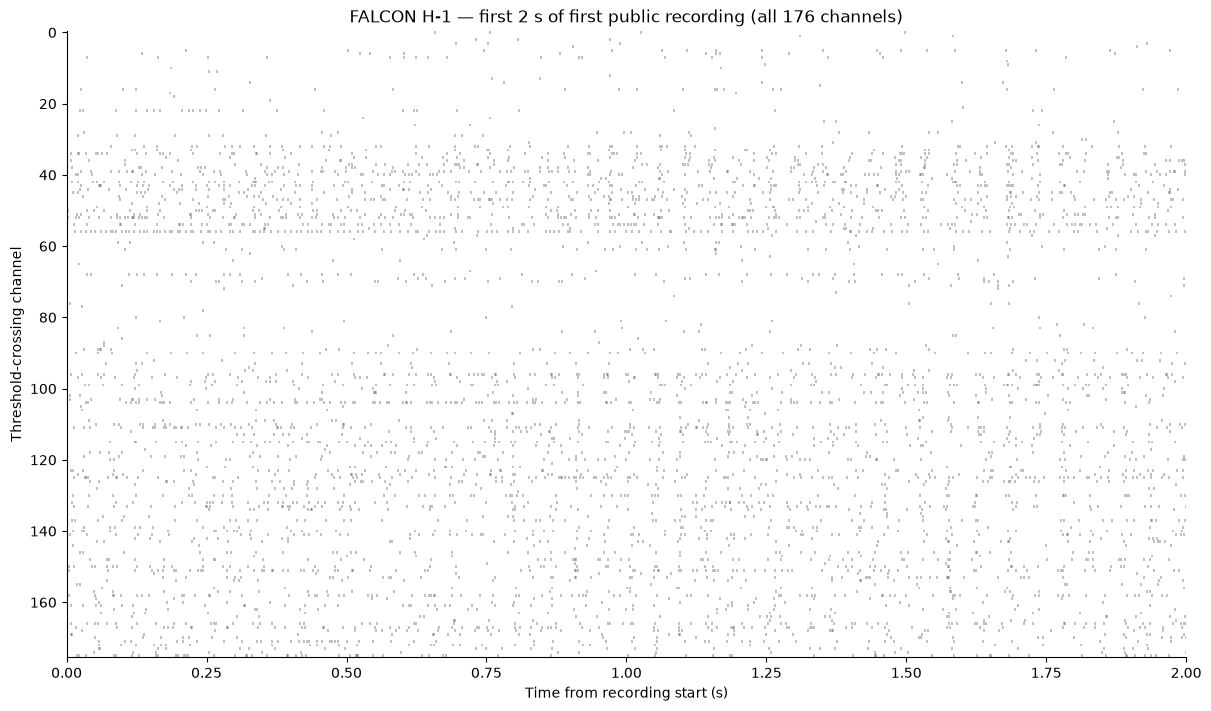

saved tutorials/figures/falcon_h1_raster.png


In [5]:
plot_raster(
    raster_spikes_for_file(calib_paths("H1")[0]),
    title="FALCON H-1 — first 2 s of first public recording (all 176 channels)",
    output=FIGURE_DIR / "falcon_h1_raster.png",
)


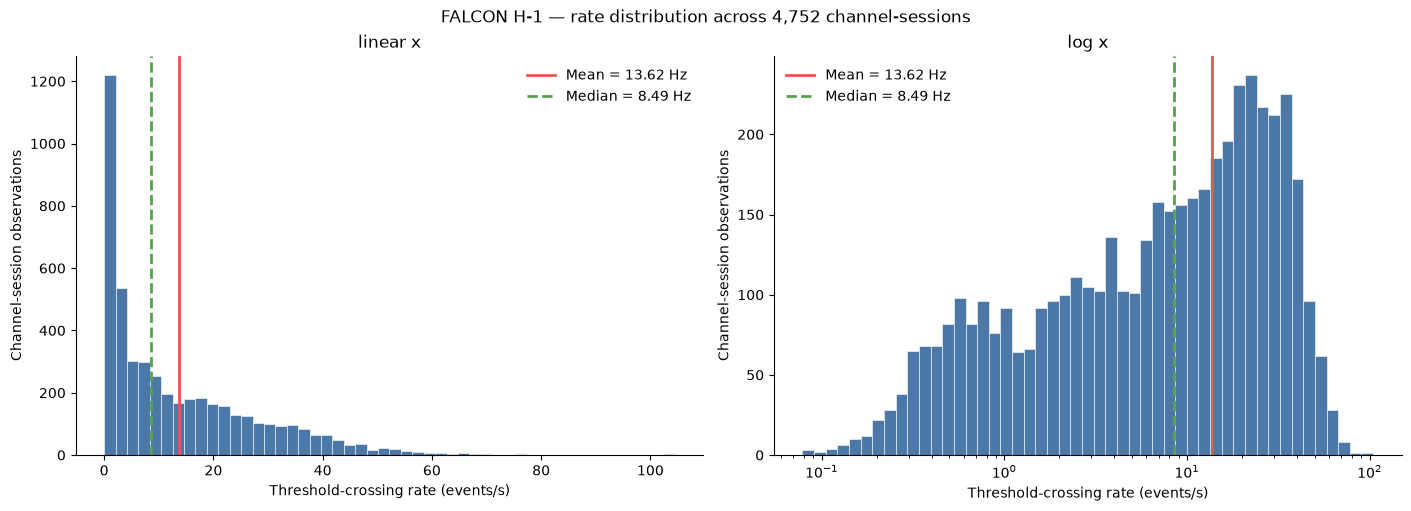

N=4,752 channel-sessions; mean=13.622 Hz; median=8.495 Hz; silent=27


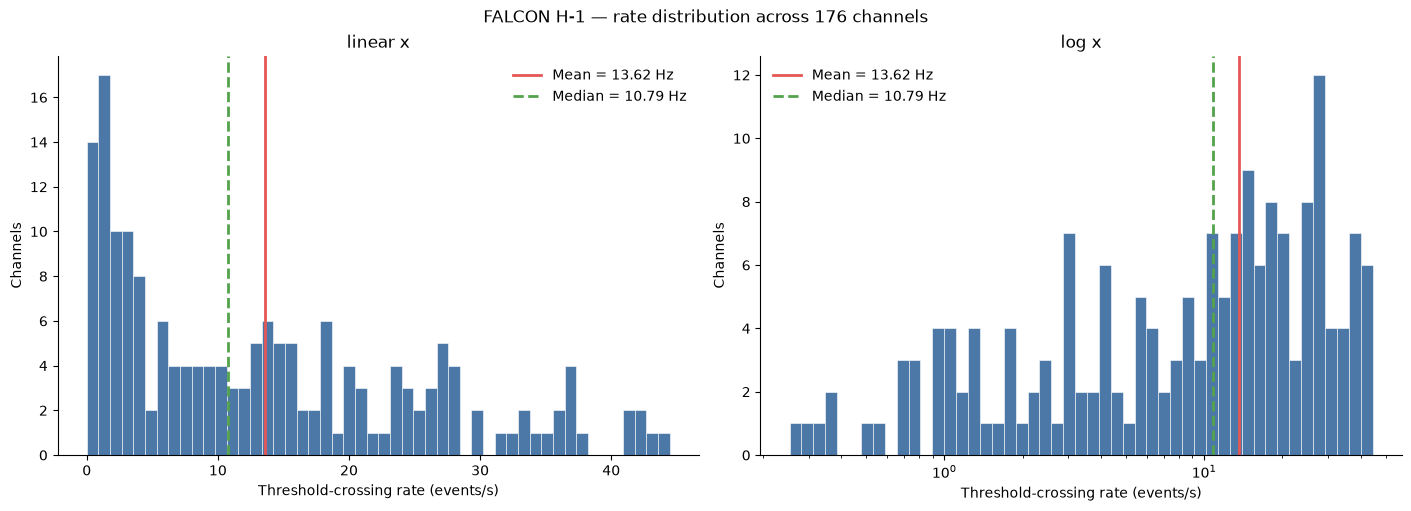

N=176 channels; mean=13.622 Hz; median=10.793 Hz; silent=1


In [6]:
show_rate_plots("FALCON H-1", h1_rates, "falcon_h1")


## H2 → spreadsheet row

- Human (T5), attempted handwriting. DANDI `000950`. Chronic Utah TCs as **20 ms counts**, not spike times.

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `acquisition/binned_spikes` | `(T, 192)` at 20 ms | CHANNELS = 192; LENGTH = `T × 20 ms` |
| `intervals/trials` | one row per cued sentence | TRIALS |
| `intervals/trials/cue` | target text, not kinematics | not a numeric column |
| spike timestamps | wall-clock, ~10 s gaps with **no bins** | do not use last−first |

**Sums**

- **TRIALS** — `len(trials/id)` summed.
- **CHANNELS** — 192 / 192.
- **LENGTH** — sum of `T × 20 ms` (matches trial durations; **not** timestamp span).
- **BENCHMARK** — retain all scientific arrays; almost entirely `binned_spikes`, excluding only schemas/container overhead.


# Verify temporal resolution across every downloaded H2 file, including minival.
h2_all_files = sorted((ROOT / "H2").rglob("*.nwb"))
h2_gap_count = 0
for path in h2_all_files:
    with h5py.File(path, "r") as f:
        assert "units" not in f
        assert "acquisition/fullband" not in f
        assert f["acquisition/binned_spikes/data"].shape[1] == 192
        timestamps = np.asarray(f["acquisition/binned_spikes/timestamps"])
        assert np.isclose(np.median(np.diff(timestamps)), 0.02)
        h2_gap_count += int(np.count_nonzero(np.diff(timestamps) > 0.021))
        neural_paths = []
        def collect_neural(name, obj):
            if isinstance(obj, h5py.Dataset) and any(token in name.lower() for token in ("spike", "volt", "elect")):
                neural_paths.append(name)
        f.visititems(collect_neural)
        assert neural_paths == ["acquisition/binned_spikes/data", "acquisition/binned_spikes/timestamps"]
print(f"H2 representation check: {len(h2_all_files)}/{len(h2_all_files)} files contain only 20 ms binned neural counts; timestamp gaps={h2_gap_count}")


In [7]:
example = calib_paths("H2")[0]
print("one file:", example.relative_to(ROOT))
with h5py.File(example, "r") as f:
    spikes = f["acquisition/binned_spikes/data"]
    ts = f["acquisition/binned_spikes/timestamps"][:]
    dt = float(np.median(np.diff(ts[:2000])))
    print("CHANNELS  binned_spikes.shape[1]     ", spikes.shape[1])
    print("TRIALS    len(intervals/trials/id)   ", len(f["intervals/trials/id"]))
    print("LENGTH    T × 20 ms                  ", spikes.shape[0] * 0.02, "s")
    print("           timestamp span (wrong)    ", float(ts[-1] - ts[0] + dt), "s")
    print("RAW       whole NWB file             ", example.stat().st_size / GB, "GB")
    print("BENCHMARK retained HDF5 arrays       ", stored_bytes(f) / GB, "GB")

h2 = inspect_dataset("H2")
display(split_breakdown(h2))
print(
    "spreadsheet H2: "
    f"SUBJECTS=1  TRIALS={int(h2.trials.sum())}  "
    f"CHANNELS {int(h2.channels.iloc[0])}/{int(h2.channels.median())}  "
    f"NEURONS N/A  LENGTH={h2.seconds.sum() / 60:.1f} min  "
    f"RAW={h2.file_bytes.sum() / GB:.3f} GB  "
    f"BENCHMARK={h2.benchmark_bytes.sum() / GB:.3f} GB"
)


one file: H2/000950/sub-T5-held-in-calib/sub-T5-held-in-calib_ses-20220518.nwb
CHANNELS  binned_spikes.shape[1]      192
TRIALS    len(intervals/trials/id)    30
LENGTH    T × 20 ms                   1266.82 s
           timestamp span (wrong)     1556.82 s
RAW       whole NWB file              0.049922021 GB
BENCHMARK retained HDF5 arrays        0.049724333 GB


,split,files,trials,minutes
0,held-in-calib,21,671,480.494333
1,held-out-calib,5,15,7.570667


spreadsheet H2: SUBJECTS=1  TRIALS=686  CHANNELS 192/192  NEURONS N/A  LENGTH=488.1 min  RAW=1.155 GB  BENCHMARK=1.149 GB


### H2 raster and rates

- **Raster** — first 2 s, all 192 channels, file order.
- **Session hist** — 192 × 26 channel-sessions. Linear x and log x.
- **Channel hist** — same 192 electrodes averaged across days.
- **Table** — one row per unique NWB; those rows sum into the spreadsheet.
- Vertical stripes are the **20 ms bin grid** (counts in a bin plotted at the bin center), not precise synchrony.


,dataset,session,split,channels,trials,neural bins,seconds,raw GB,benchmark GB,mean event rate (Hz),median event rate (Hz)
0,H2,sub-T5-held-in-calib_ses-20220518,held-in-calib,192,30,63341,1266.82,0.049922,0.049724,10.160000,2.320000
1,H2,sub-T5-held-in-calib_ses-20220523,held-in-calib,192,48,107779,2155.58,0.084808,0.084609,10.230000,2.070000
2,H2,sub-T5-held-in-calib_ses-20220525,held-in-calib,192,36,115725,2314.50,0.091035,0.090846,9.220000,1.480000
3,H2,sub-T5-held-in-calib_ses-20220601,held-in-calib,192,48,109094,2181.88,0.085840,0.085641,9.900000,2.260000
4,H2,sub-T5-held-in-calib_ses-20220603,held-in-calib,192,48,74772,1495.44,0.058897,0.058699,8.300000,1.670000
5,H2,sub-T5-held-in-calib_ses-20220606,held-in-calib,192,47,134760,2695.20,0.105990,0.105789,11.140000,1.760000
6,H2,sub-T5-held-in-calib_ses-20220608,held-in-calib,192,25,84261,1685.22,0.066344,0.066146,10.910000,1.320000
7,H2,sub-T5-held-in-calib_ses-20220613,held-in-calib,192,48,107977,2159.54,0.084965,0.084764,10.820000,1.730000
8,H2,sub-T5-held-in-calib_ses-20220615,held-in-calib,192,36,83385,1667.70,0.065648,0.065459,12.600000,3.270000
9,H2,sub-T5-held-in-calib_ses-20220622,held-in-calib,192,48,93113,1862.26,0.073297,0.073096,11.340000,2.230000


audit totals: sessions=26, trials=686, minutes=488.065, raw=1.155 GB, benchmark=1.149 GB


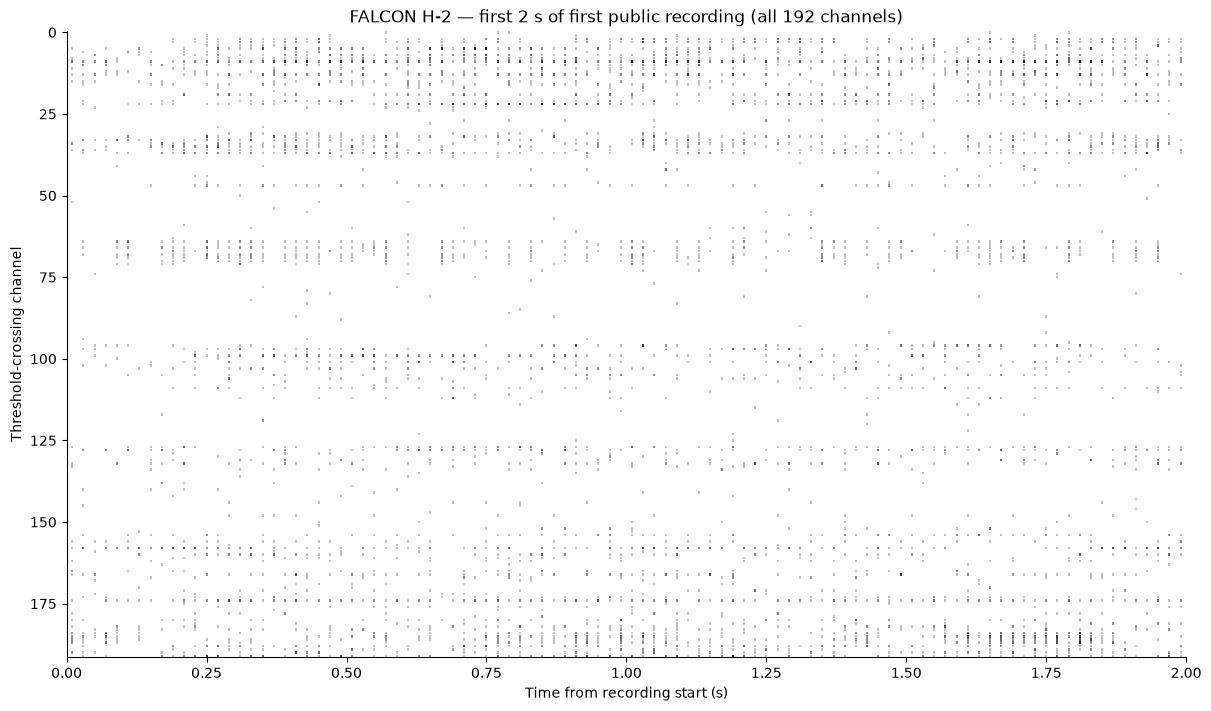

saved tutorials/figures/falcon_h2_raster.png


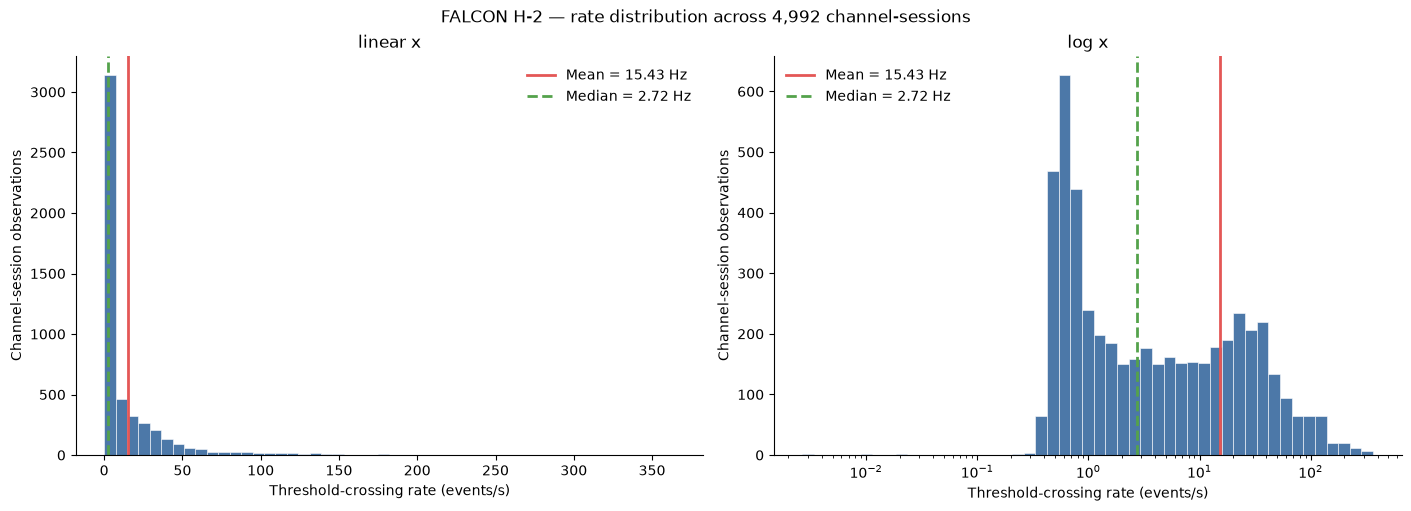

N=4,992 channel-sessions; mean=15.428 Hz; median=2.724 Hz; silent=0


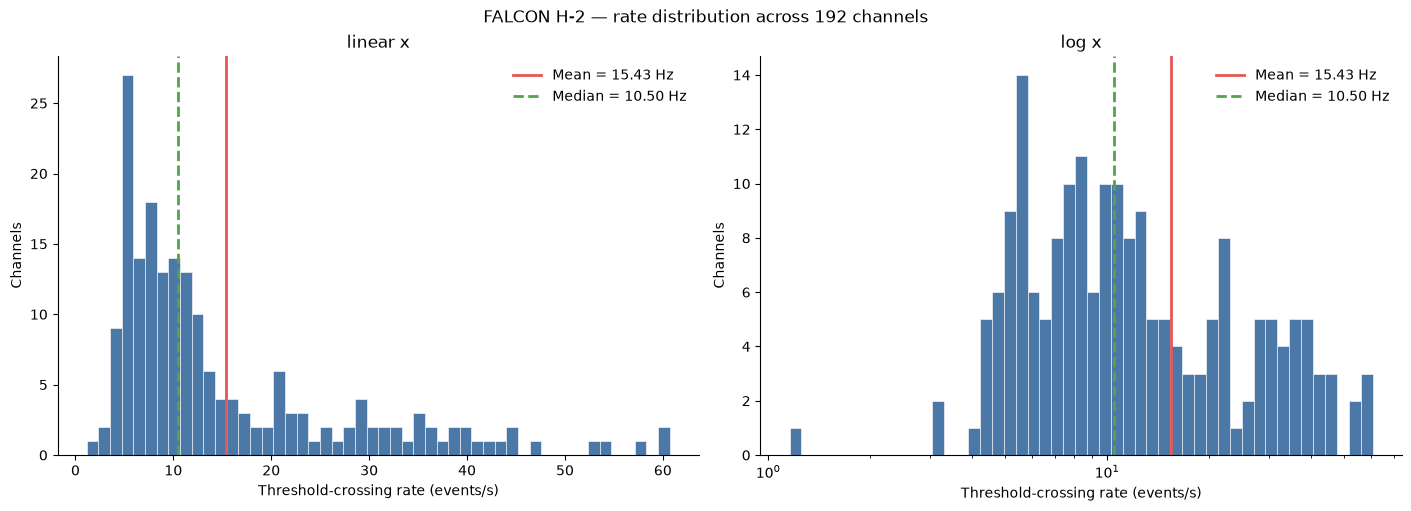

N=192 channels; mean=15.428 Hz; median=10.504 Hz; silent=0


In [8]:
h2_session_audit, h2_rates = session_audit("H2")
show_audit(h2_session_audit)
plot_raster(
    raster_spikes_for_file(calib_paths("H2")[0]),
    title="FALCON H-2 — first 2 s of first public recording (all 192 channels)",
    output=FIGURE_DIR / "falcon_h2_raster.png",
)
show_rate_plots("FALCON H-2", h2_rates, "falcon_h2")


## M1 → spreadsheet row

- Two monkeys, two DANDIets, **one spreadsheet row**. Reach/grasp + 16-muscle EMG.
- M1-A = Monkey L `000941`. M1-B = Monkey X `001209`. Both **64** channels (not the figure’s 64/96). Chronic FMAs, not Utah.

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `units/id` | 64 threshold-crossing channels | CHANNELS |
| `intervals/trials/id` | one reach/grasp trial | TRIALS (all `result=R`) |
| `units/obs_intervals` | spike observation span, includes inter-trial time | LENGTH |
| `preprocessed_emg/<muscle>/data` | 16 EMG streams | size and decode target, not a column |

**Sums**

- **SUBJECTS** — 2.
- **TRIALS** — M1-A + M1-B.
- **CHANNELS** — total 64+64 = 128 (not simultaneous); median 64.
- **LENGTH** — sum of observation spans.
- **BENCHMARK** — retain spikes + EMG + trials; exclude schemas/container overhead.


In [9]:
example = calib_paths("M1-A")[0]
print("one M1-A file:", example.relative_to(ROOT))
with h5py.File(example, "r") as f:
    obs = np.asarray(f["units/obs_intervals"])
    muscles = list(f["acquisition/preprocessed_emg"].keys())
    print("CHANNELS  len(units/id)              ", len(f["units/id"]))
    print("TRIALS    len(intervals/trials/id)   ", len(f["intervals/trials/id"]))
    print("LENGTH    obs_intervals span         ", float(obs[:, 1].max() - obs[:, 0].min()), "s")
    print("           EMG muscles               ", len(muscles))
    print("RAW       whole NWB file             ", example.stat().st_size / GB, "GB")
    print("BENCHMARK retained HDF5 arrays       ", stored_bytes(f) / GB, "GB")

m1a = inspect_dataset("M1-A")
m1b = inspect_dataset("M1-B")
m1 = pd.concat([m1a, m1b], ignore_index=True)
print("M1-A"); display(split_breakdown(m1a))
print("M1-B"); display(split_breakdown(m1b))
print(
    "spreadsheet M1: "
    f"SUBJECTS=2  TRIALS={int(m1.trials.sum())}  "
    f"CHANNELS {int(m1a.channels.iloc[0] + m1b.channels.iloc[0])}/{int(np.median(m1.channels))}  "
    f"NEURONS N/A  LENGTH={m1.seconds.sum() / 60:.1f} min  "
    f"RAW={m1.file_bytes.sum() / GB:.3f} GB  "
    f"BENCHMARK={m1.benchmark_bytes.sum() / GB:.3f} GB"
)


one M1-A file: M1-A/000941/sub-MonkeyL-held-in-calib/sub-MonkeyL-held-in-calib_ses-20120924_behavior+ecephys.nwb
CHANNELS  len(units/id)               64
TRIALS    len(intervals/trials/id)    414
LENGTH    obs_intervals span          3649.953 s
           EMG muscles                16
RAW       whole NWB file              0.073077382 GB
BENCHMARK retained HDF5 arrays        0.072779382 GB
M1-A


,split,files,trials,minutes
0,held-in-calib,4,1611,230.954550
1,held-out-calib,3,30,4.484817


M1-B


,split,files,trials,minutes
0,held-in-calib,4,1691,221.347850
1,held-out-calib,4,40,5.999133


spreadsheet M1: SUBJECTS=2  TRIALS=3372  CHANNELS 128/64  NEURONS N/A  LENGTH=462.8 min  RAW=0.541 GB  BENCHMARK=0.537 GB


### M1 raster and rates

- **Raster** — first 2 s of the first M1-A file, 64 FMA channels, file order.
- **Session hist** — 64 × 15 files (both monkeys). Linear x and log x.
- **Channel hist** — 128 electrodes (64 per monkey); Monkey L channel 0 ≠ Monkey X channel 0.
- **Table** — one row per unique NWB; those rows sum into the spreadsheet.


,dataset,session,split,channels,trials,neural bins,seconds,raw GB,benchmark GB,mean event rate (Hz),median event rate (Hz)
0,M1-A,sub-MonkeyL-held-in-calib_ses-20120924_behavior+ecephys,held-in-calib,64,414,None,3649.95,0.073077,0.072779,13.04,6.15
1,M1-A,sub-MonkeyL-held-in-calib_ses-20120926_behavior+ecephys,held-in-calib,64,409,None,3446.50,0.080268,0.079972,19.41,7.57
2,M1-A,sub-MonkeyL-held-in-calib_ses-20120927_behavior+ecephys,held-in-calib,64,376,None,3552.12,0.078482,0.078185,17.08,4.97
3,M1-A,sub-MonkeyL-held-in-calib_ses-20120928_behavior+ecephys,held-in-calib,64,412,None,3208.70,0.068337,0.068041,15.50,8.12
4,M1-A,sub-MonkeyL-held-out-calib_ses-20121004_behavior+ecephys,held-out-calib,64,10,None,68.84,0.002606,0.002327,39.88,24.42
5,M1-A,sub-MonkeyL-held-out-calib_ses-20121017_behavior+ecephys,held-out-calib,64,10,None,66.84,0.002710,0.002432,44.89,25.69
6,M1-A,sub-MonkeyL-held-out-calib_ses-20121024_behavior+ecephys,held-out-calib,64,10,None,133.42,0.003778,0.003500,25.21,8.36
7,M1-B,sub-MonkeyX-held-in-calib_ses-20121206_behavior+ecephys,held-in-calib,64,395,None,3608.87,0.059353,0.059057,6.05,0.83
8,M1-B,sub-MonkeyX-held-in-calib_ses-20121207_behavior+ecephys,held-in-calib,64,429,None,3142.68,0.052469,0.052181,6.51,0.42
9,M1-B,sub-MonkeyX-held-in-calib_ses-20121210_behavior+ecephys,held-in-calib,64,446,None,3217.98,0.055431,0.055134,7.55,1.05


audit totals: sessions=15, trials=3372, minutes=462.786, raw=0.541 GB, benchmark=0.537 GB


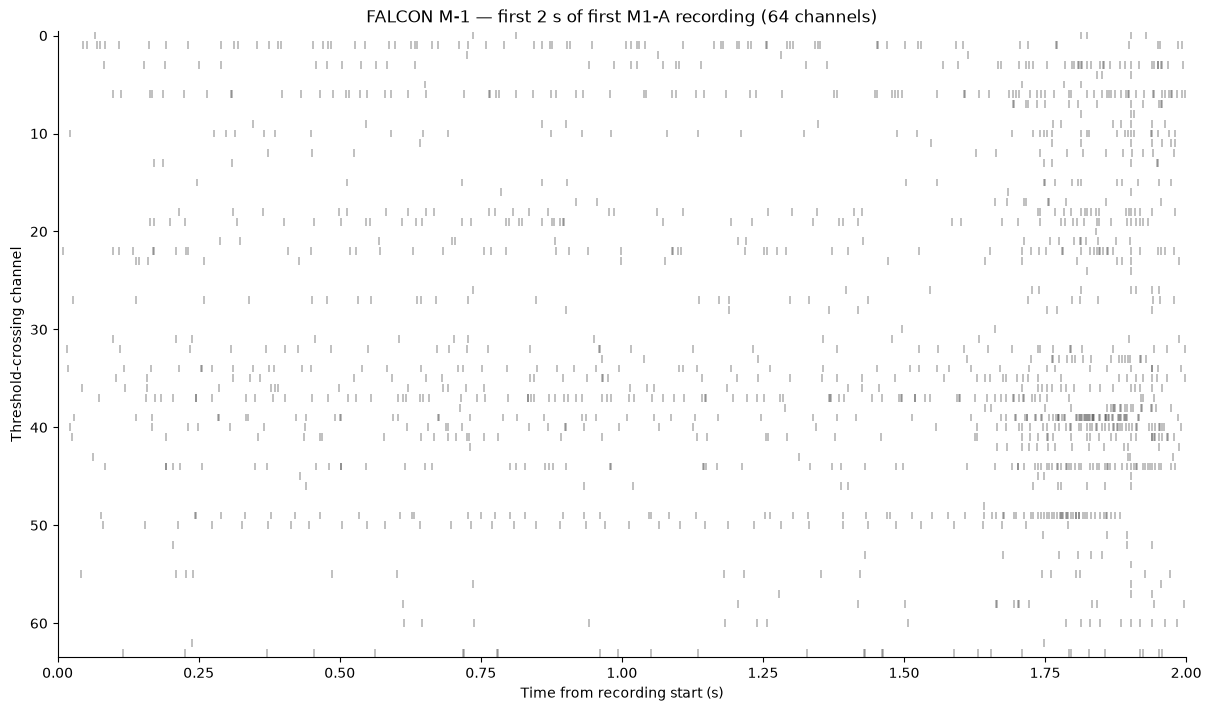

saved tutorials/figures/falcon_m1_raster.png


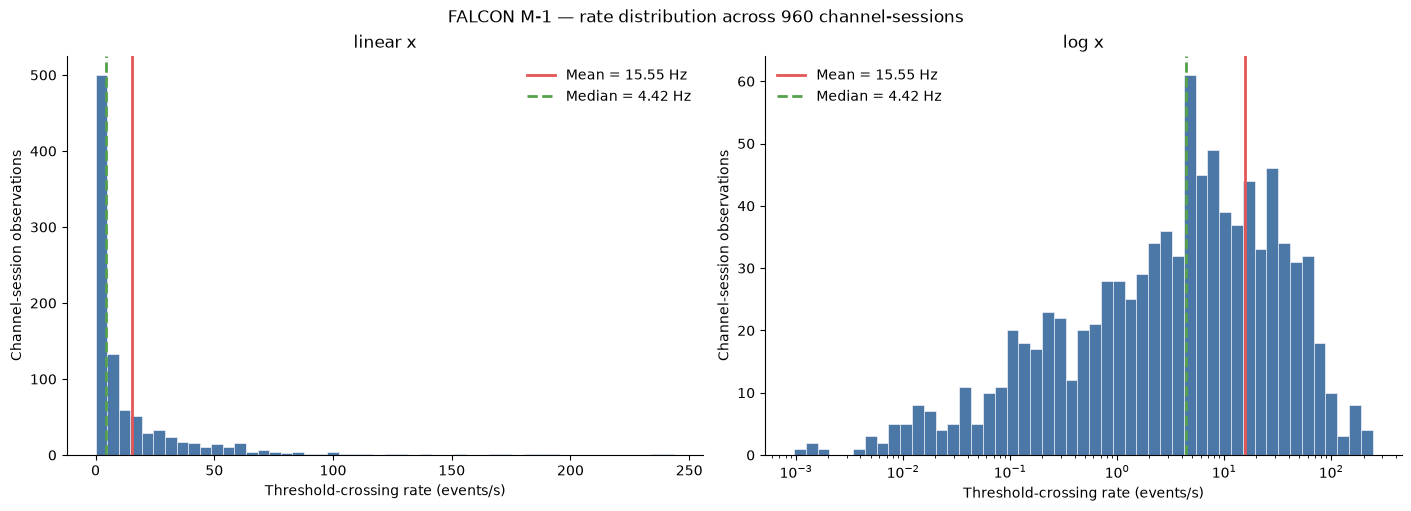

N=960 channel-sessions; mean=15.547 Hz; median=4.416 Hz; silent=19


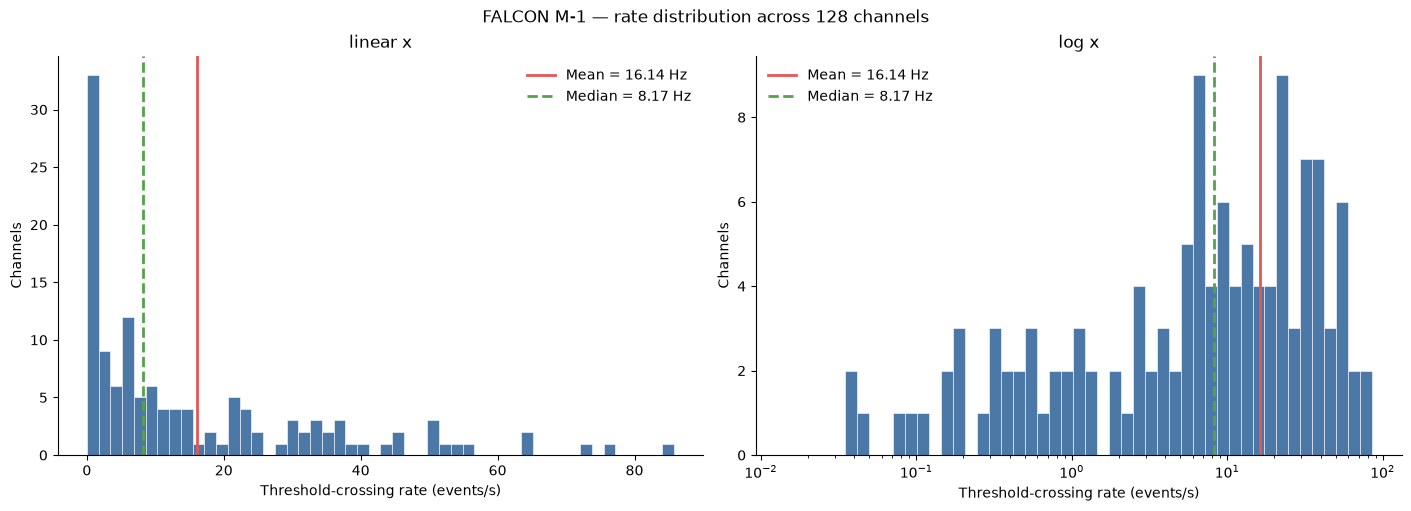

N=128 channels; mean=16.138 Hz; median=8.167 Hz; silent=0


In [10]:
m1_session_audit, m1_rates = session_audit(("M1-A", "M1-B"))
show_audit(m1_session_audit)
plot_raster(
    raster_spikes_for_file(calib_paths("M1-A")[0]),
    title="FALCON M-1 — first 2 s of first M1-A recording (64 channels)",
    output=FIGURE_DIR / "falcon_m1_raster.png",
)
show_rate_plots("FALCON M-1", m1_rates, "falcon_m1")


## M2 → spreadsheet row

- One macaque (Monkey N), finger movements. DANDI `000953`. Chronic 96-ch TCs.

**In a file**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `units/id` | 96 threshold-crossing channels | CHANNELS |
| `intervals/trials/id` | finger-movement trials | TRIALS |
| `units/obs_intervals` | observation span | LENGTH |
| `finger_pos/index`, `finger_pos/mrs` | kinematics target | size, not a column |
| `acquisition/fullband` | 30 kHz raw voltage, ~all of the download | **RAW only; drop from BENCHMARK** |

**Sums**

- **CHANNELS** — 96 / 96.
- **TRIALS / LENGTH** — sum of per-file counts / spans.
- **RAW** — sum of NWB file sizes (includes fullband, ≈15.79 GB).
- **BENCHMARK** — file size minus `fullband` (≈0.021 GB of spikes + fingers + file wrapper).


In [11]:
example = calib_paths("M2")[0]
print("one file:", example.relative_to(ROOT))
with h5py.File(example, "r") as f:
    fb = f["acquisition/fullband/data"]
    print("CHANNELS  len(units/id)              ", len(f["units/id"]))
    print("TRIALS    len(intervals/trials/id)   ", len(f["intervals/trials/id"]))
    print("LENGTH    obs_intervals              ", recording_seconds(f), "s")
    print("           finger_pos                ", list(f["acquisition/finger_pos"].keys()))
    print("           fullband (excluded)       ", fb.shape, fb.dtype)
    dropped = prefix_bytes(f, "acquisition/fullband/")
    print("RAW       whole NWB file             ", example.stat().st_size / GB, "GB")
    print("           fullband allocated        ", dropped / GB, "GB")
    print("BENCHMARK retained arrays, no fullband", stored_bytes(f, skip_prefixes=("acquisition/fullband/",)) / GB, "GB")

m2 = inspect_dataset("M2")
display(split_breakdown(m2))
print(
    "spreadsheet M2: "
    f"SUBJECTS=1  TRIALS={int(m2.trials.sum())}  "
    f"CHANNELS {int(m2.channels.iloc[0])}/{int(m2.channels.median())}  "
    f"NEURONS N/A  LENGTH={m2.seconds.sum() / 60:.1f} min  "
    f"RAW={m2.file_bytes.sum() / GB:.3f} GB  "
    f"BENCHMARK={m2.benchmark_bytes.sum() / GB:.3f} GB"
)


one file: M2/000953/sub-MonkeyN-held-in-calib/sub-MonkeyN-held-in-calib_ses-2020-10-19-Run1_behavior+ecephys.nwb
CHANNELS  len(units/id)               96
TRIALS    len(intervals/trials/id)    337
LENGTH    obs_intervals               399.181 s
           finger_pos                 ['index', 'mrs']
           fullband (excluded)        (11970616, 96) int16
RAW       whole NWB file              2.397151103 GB
           fullband allocated         2.394123968 GB
BENCHMARK retained arrays, no fullband 0.002787759 GB


,split,files,trials,minutes
0,held-in-calib,7,1923,38.655917
1,held-out-calib,6,234,5.135183


spreadsheet M2: SUBJECTS=1  TRIALS=2157  CHANNELS 96/96  NEURONS N/A  LENGTH=43.8 min  RAW=15.792 GB  BENCHMARK=0.017 GB


### M2 raster and rates

- **Raster** — first 2 s, all 96 channels, file order. Spike times, not the raw voltage.
- **Session hist** — 96 × 13 channel-sessions. Linear x and log x.
- **Channel hist** — same 96 electrodes averaged across days.
- **Table** — one row per unique NWB; those rows sum into the spreadsheet.


,dataset,session,split,channels,trials,neural bins,seconds,raw GB,benchmark GB,mean event rate (Hz),median event rate (Hz)
0,M2,sub-MonkeyN-held-in-calib_ses-2020-10-19-Run1_behavior+ecephys,held-in-calib,96,337,None,399.18,2.397151,0.002788,5.30,0.45
1,M2,sub-MonkeyN-held-in-calib_ses-2020-10-19-Run2_behavior+ecephys,held-in-calib,96,339,None,401.62,2.407211,0.002731,5.06,0.47
2,M2,sub-MonkeyN-held-in-calib_ses-2020-10-20-Run1_behavior+ecephys,held-in-calib,96,248,None,312.86,1.879943,0.002013,4.57,0.63
3,M2,sub-MonkeyN-held-in-calib_ses-2020-10-20-Run2_behavior+ecephys,held-in-calib,96,245,None,310.88,1.866626,0.001969,4.44,0.55
4,M2,sub-MonkeyN-held-in-calib_ses-2020-10-27-Run1_behavior+ecephys,held-in-calib,96,204,None,244.98,1.470731,0.001465,3.96,0.52
5,M2,sub-MonkeyN-held-in-calib_ses-2020-10-27-Run2_behavior+ecephys,held-in-calib,96,251,None,294.18,1.773775,0.001777,4.05,0.56
6,M2,sub-MonkeyN-held-in-calib_ses-2020-10-28-Run1_behavior+ecephys,held-in-calib,96,299,None,355.65,2.137463,0.002458,5.19,0.73
7,M2,sub-MonkeyN-held-out-calib_ses-2020-10-30-Run1_behavior+ecephys,held-out-calib,96,43,None,54.54,0.329104,0.000384,5.11,0.72
8,M2,sub-MonkeyN-held-out-calib_ses-2020-10-30-Run2_behavior+ecephys,held-out-calib,96,41,None,51.00,0.307735,0.000342,4.64,0.66
9,M2,sub-MonkeyN-held-out-calib_ses-2020-11-18-Run1_behavior+ecephys,held-out-calib,96,41,None,50.36,0.303915,0.000388,5.94,1.39


audit totals: sessions=13, trials=2157, minutes=43.791, raw=15.792 GB, benchmark=0.017 GB


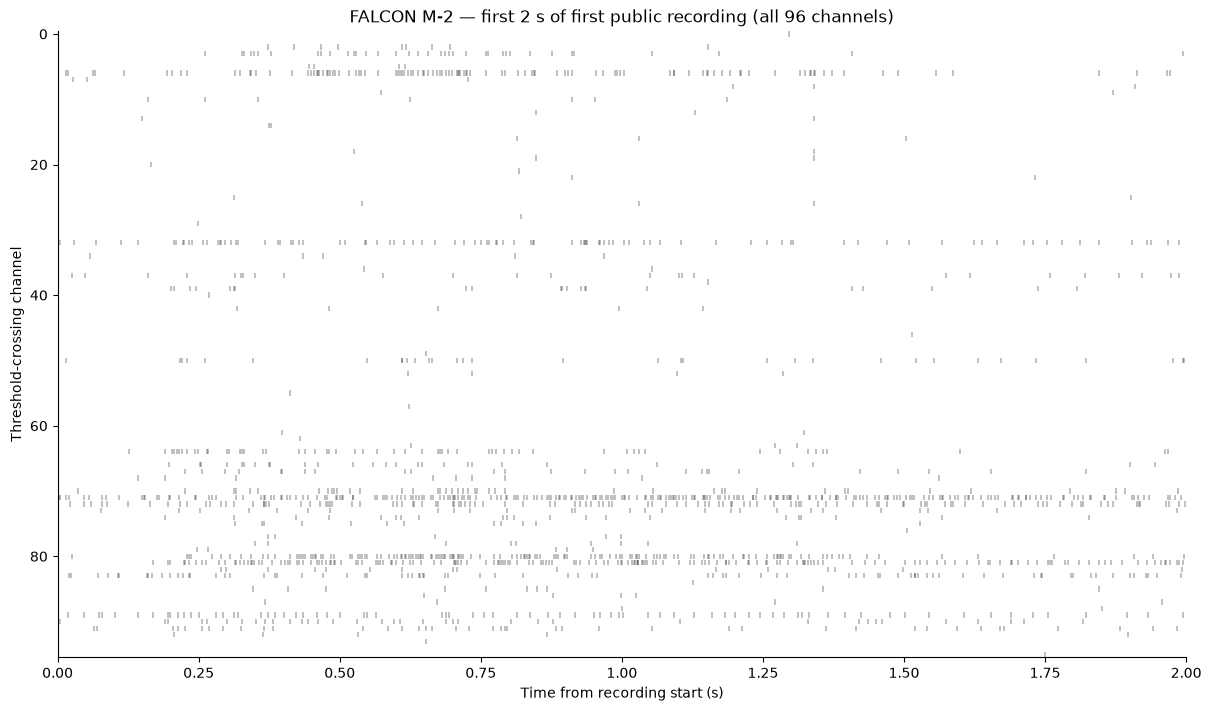

saved tutorials/figures/falcon_m2_raster.png


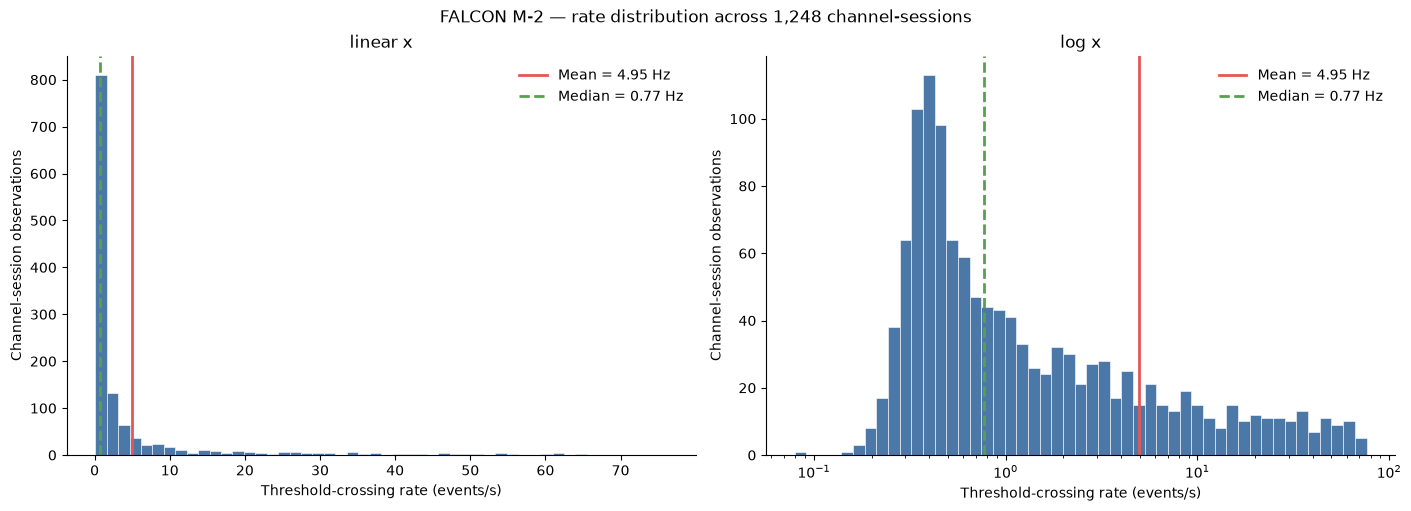

N=1,248 channel-sessions; mean=4.954 Hz; median=0.770 Hz; silent=0


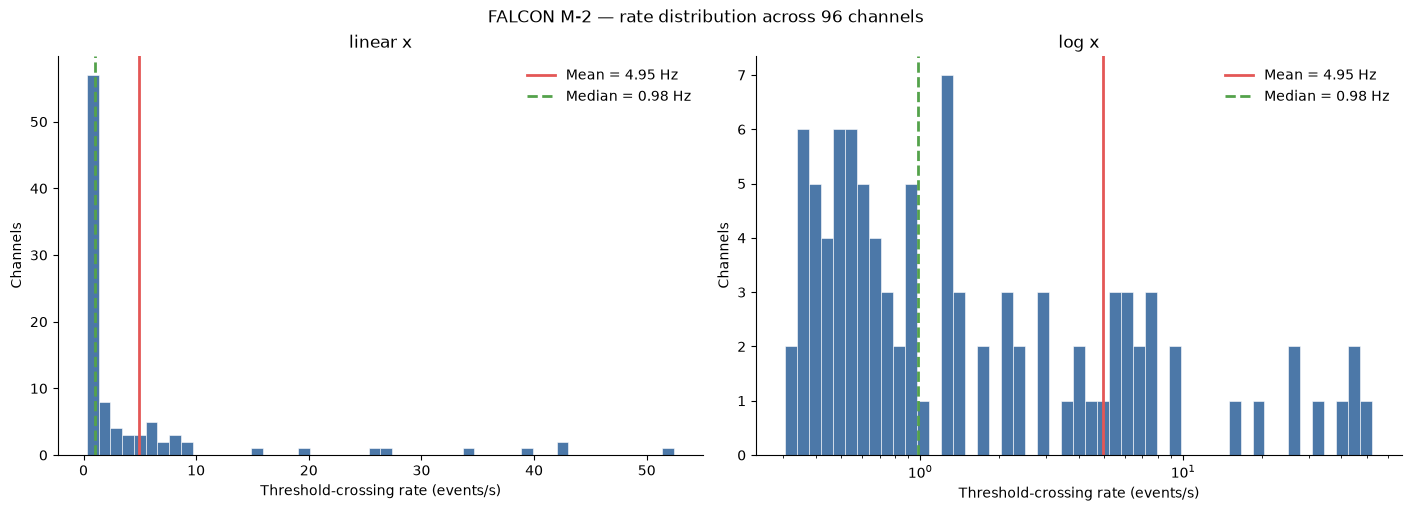

N=96 channels; mean=4.954 Hz; median=0.978 Hz; silent=0


In [12]:
m2_session_audit, m2_rates = session_audit("M2")
show_audit(m2_session_audit)
plot_raster(
    raster_spikes_for_file(calib_paths("M2")[0]),
    title="FALCON M-2 — first 2 s of first public recording (all 96 channels)",
    output=FIGURE_DIR / "falcon_m2_raster.png",
)
show_rate_plots("FALCON M-2", m2_rates, "falcon_m2")


## B1 → spreadsheet row

- One zebra finch, song motifs. DANDI `001046`. Acute Neuropixels, 6 calib days.
- One file = concatenated ~0.9 s motifs, not a full day.

**In a file (one day)**

| Field | What it is | Spreadsheet? |
|---|---|---|
| `acquisition/tx` | `(T, 85)` at **30 kHz**, not 20 ms | CHANNELS = 85; LENGTH = `T × dt` |
| `intervals/trials` | ~0.9 s song motifs | TRIALS |
| spectrograms on the trial table | decode target | included in BENCHMARK DATASET SIZE |
| `vocalizations` | 25 kHz audio | included in BENCHMARK DATASET SIZE |

**Sums**

- **TRIALS** — motifs summed (48 held-in + 9 held-out = 57).
- **CHANNELS** — median 85 (one day); total 85 × 6 = 510 (not simultaneous).
- **LENGTH** — sum of motif time (under 1 min).
- **BENCHMARK** — keeps the dense 30 kHz `tx` plus spectrograms and audio (~1.16 GB), excluding only schemas/container overhead. A 20 ms binned tensor would be tiny; that is not this column.


In [13]:
example = calib_paths("B1")[0]
print("one file:", example.relative_to(ROOT))
with h5py.File(example, "r") as f:
    tx = f["acquisition/tx/data"]
    dt = median_dt(f["acquisition/tx/timestamps"])
    print("CHANNELS  tx.shape[1]                ", tx.shape[1])
    print("TRIALS    len(intervals/trials/id)   ", len(f["intervals/trials/id"]), "motifs")
    print("LENGTH    T × dt                     ", len(tx) * dt, "s  (30 kHz)")
    print("RAW       whole NWB file             ", example.stat().st_size / GB, "GB")
    print("BENCHMARK retained HDF5 arrays       ", stored_bytes(f) / GB, "GB")

b1 = inspect_dataset("B1")
display(split_breakdown(b1))
n_days = len(b1)
print(
    "spreadsheet B1: "
    f"SUBJECTS=1  TRIALS={int(b1.trials.sum())}  "
    f"CHANNELS {int(b1.channels.iloc[0]) * n_days}/{int(b1.channels.median())}  "
    f"NEURONS N/A  LENGTH={b1.seconds.sum() / 60:.3f} min  "
    f"RAW={b1.file_bytes.sum() / GB:.3f} GB  "
    f"BENCHMARK={b1.benchmark_bytes.sum() / GB:.3f} GB"
)


# The rates are high because these are unsorted, multiunit threshold crossings with independently chosen per-channel thresholds, not isolated-neuron firing rates. The validation below confirms that every nonzero sample is a single-sample binary event; the rate is not inflated by counting a multi-sample pulse more than once.

one file: B1/001046/sub-Finch-z-r12r13-21-held-in-calib/sub-Finch-z-r12r13-21-held-in-calib_ses-20210626.nwb
CHANNELS  tx.shape[1]                 85
TRIALS    len(intervals/trials/id)    11 motifs
LENGTH    T × dt                      9.89999999999994 s  (30 kHz)
RAW       whole NWB file              0.224583316 GB
BENCHMARK retained HDF5 arrays        0.224380276 GB


,split,files,trials,minutes
0,held-in-calib,3,48,0.720
1,held-out-calib,3,9,0.135


spreadsheet B1: SUBJECTS=1  TRIALS=57  CHANNELS 510/85  NEURONS N/A  LENGTH=0.855 min  RAW=1.164 GB  BENCHMARK=1.163 GB


### B1 raster and rates

- **Raster** — first 2 s, all 85 channels, file order. 30 kHz `tx` at bin centers.
- **Session hist** — 85 × 6 = 510 channel-sessions. Linear x and log x.
- No **channel hist** — Neuropixels days are different insertions, so channel 3 on day 1 is not channel 3 on day 2.
- **Table** — one row per unique NWB; those rows sum into the spreadsheet.


# Confirm that the high B1 rates are present in the released data rather than
# an error caused by counting multi-sample threshold pulses.
b1_session_diagnostics = []
for path in calib_paths("B1"):
    with h5py.File(path, "r") as f:
        dset = f["acquisition/tx/data"]
        timestamps = f["acquisition/tx/timestamps"]
        dt = median_dt(timestamps)
        ones = np.zeros(dset.shape[1], dtype=np.int64)
        adjacent = 0
        previous = np.zeros(dset.shape[1], dtype=bool)
        for start in range(0, dset.shape[0], 100_000):
            block = np.asarray(dset[start : start + 100_000])
            assert np.all((block == 0) | (block == 1))
            binary = block.astype(bool)
            preceding = np.vstack([previous, binary[:-1]])
            adjacent += int(np.count_nonzero(preceding & binary))
            ones += block.sum(axis=0, dtype=np.int64)
            previous = binary[-1]
        duration = len(dset) * dt
        b1_session_diagnostics.append(
            {
                "session": path.stem,
                "seconds": duration,
                "mean rate (events/s/channel)": ones.mean() / duration,
                "median rate (events/s/channel)": np.median(ones / duration),
                "adjacent event samples": adjacent,
            }
        )
b1_binary_check = pd.DataFrame(b1_session_diagnostics)
display(b1_binary_check.round(3))
assert b1_binary_check["adjacent event samples"].eq(0).all()
print("B1 representation check: binary 30 kHz events in all 6 sessions; no adjacent nonzero samples")


,dataset,session,split,channels,trials,neural bins,seconds,raw GB,benchmark GB,mean event rate (Hz),median event rate (Hz)
0,B1,sub-Finch-z-r12r13-21-held-in-calib_ses-20210626,held-in-calib,85,11,297000,9.9,0.224583,0.224380,236.91,243.74
1,B1,sub-Finch-z-r12r13-21-held-in-calib_ses-20210627,held-in-calib,85,29,783000,26.1,0.591750,0.591548,241.62,247.16
2,B1,sub-Finch-z-r12r13-21-held-in-calib_ses-20210628,held-in-calib,85,8,216000,7.2,0.163389,0.163186,256.21,256.53
3,B1,sub-Finch-z-r12r13-21-held-out-calib_ses-20210630,held-out-calib,85,3,81000,2.7,0.061398,0.061195,260.85,265.93
4,B1,sub-Finch-z-r12r13-21-held-out-calib_ses-20210701,held-out-calib,85,3,81000,2.7,0.061398,0.061195,270.49,275.19
5,B1,sub-Finch-z-r12r13-21-held-out-calib_ses-20210705,held-out-calib,85,3,81000,2.7,0.061398,0.061195,272.74,284.44


audit totals: sessions=6, trials=57, minutes=0.855, raw=1.164 GB, benchmark=1.163 GB


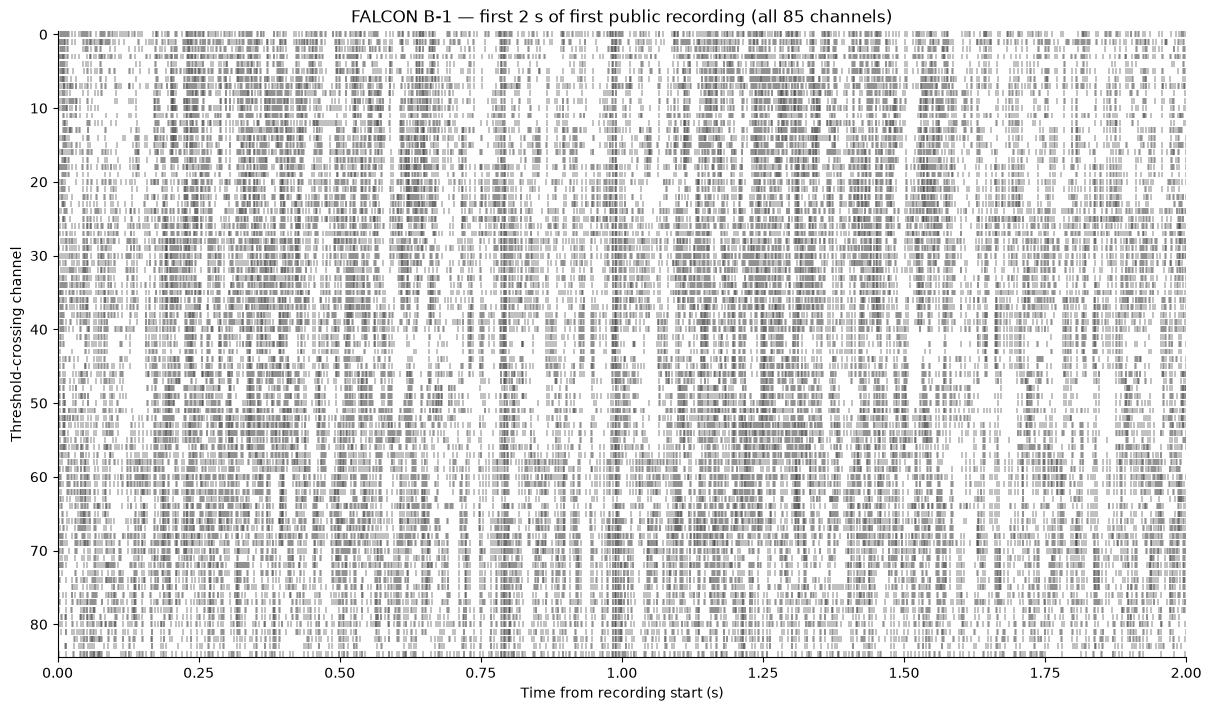

saved tutorials/figures/falcon_b1_raster.png


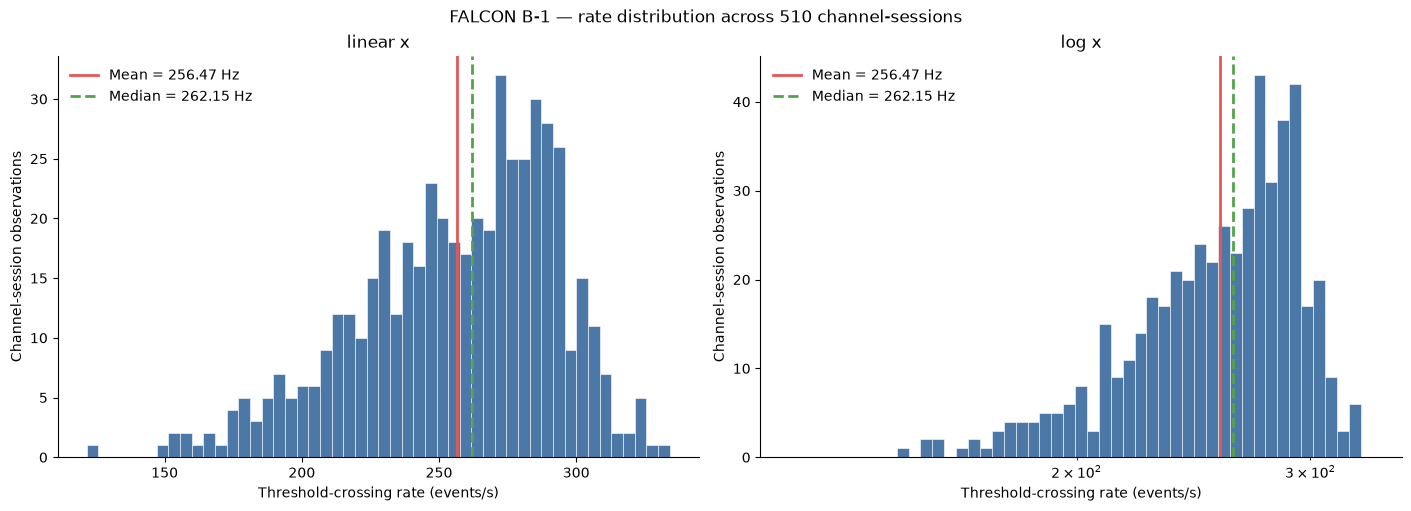

N=510 channel-sessions; mean=256.470 Hz; median=262.146 Hz; silent=0


In [14]:
b1_session_audit, b1_rates = session_audit("B1")
show_audit(b1_session_audit)
plot_raster(
    raster_spikes_for_file(calib_paths("B1")[0]),
    title="FALCON B-1 — first 2 s of first public recording (all 85 channels)",
    output=FIGURE_DIR / "falcon_b1_raster.png",
)
show_rate_plots("FALCON B-1", b1_rates, "falcon_b1", channel_average=False)


## Spreadsheet

- Add the per-dataset sums.
- Length: 1 decimal minute, except B1 (3 decimals). RAW and BENCHMARK: 3 decimal GB.
- This cell writes `tutorials/falcon_datasets.csv`.


In [15]:
def round_minutes(minutes: float) -> float:
    return round(minutes, 3) if minutes < 1 else round(minutes, 1)


def spreadsheet_row(name, animal, subjects, frame, *, total_channels, notes, basic_stats) -> dict[str, object]:
    return {
        "DATASET": name,
        "ANIMAL": animal,
        "SUBJECTS": subjects,
        "TRIALS": int(frame["trials"].sum()),
        "TOTAL CHANNELS": int(total_channels),
        "MEDIAN CHANNELS": int(np.median(frame["channels"])),
        "TOTAL NEURONS": "N/A",
        "MEDIAN NEURONS": "N/A",
        "RECORDING LENGTH (min)": round_minutes(float(frame["seconds"].sum() / 60)),
        "RAW DATASET SIZE (GB)": round(float(frame["file_bytes"].sum()) / GB, 3),
        "BENCHMARK DATASET SIZE (GB)": round(float(frame["benchmark_bytes"].sum()) / GB, 3),
        "NOTES": notes,
        "BASIC STATS": basic_stats,
    }


def n_split(frame, split):
    return int(frame.loc[frame.split == split, "trials"].sum())


inventory = pd.DataFrame(
    [
        spreadsheet_row(
            "FALCON H1", "Human", 1, h1,
            total_channels=int(h1.channels.iloc[0]),
            notes=(
                f"{n_split(h1, 'held-in-calib'):,} held-in + {n_split(h1, 'held-out-calib'):,} held-out trials "
                f"across {len(h1)} calibration files; attempted 7-DoF reach/grasp; "
                "threshold crossings stored as per-channel spike times; NWB epoch rows are movement phases, not trials."
            ),
            basic_stats=f"Channel-session event rate: mean {h1_rates.rate_hz.mean():.2f}, median {h1_rates.rate_hz.median():.2f} events/s",
        ),
        spreadsheet_row(
            "FALCON H2", "Human", 1, h2,
            total_channels=int(h2.channels.iloc[0]),
            notes=(
                f"{n_split(h2, 'held-in-calib'):,} held-in + {n_split(h2, 'held-out-calib'):,} held-out trials "
                f"across {len(h2)} calibration files; attempted handwriting; "
                f"duration is {int(round(float(h2.seconds.sum()) / 0.02)):,} recorded 20 ms bins and excludes unsampled inter-sentence timestamp gaps."
            ),
            basic_stats=f"Channel-session event rate: mean {h2_rates.rate_hz.mean():.2f}, median {h2_rates.rate_hz.median():.2f} events/s",
        ),
        spreadsheet_row(
            "FALCON M1", "Rhesus macaque", 2, m1,
            total_channels=int(m1a.channels.iloc[0] + m1b.channels.iloc[0]),
            notes=(
                f"M1-A and M1-B combined: {n_split(m1, 'held-in-calib'):,} held-in + {n_split(m1, 'held-out-calib'):,} "
                f"held-out trials across {len(m1)} calibration files; 64 simultaneous channels per monkey; "
                "16-muscle EMG target."
            ),
            basic_stats=f"Channel-session event rate: mean {m1_rates.rate_hz.mean():.2f}, median {m1_rates.rate_hz.median():.2f} events/s",
        ),
        spreadsheet_row(
            "FALCON M2", "Rhesus macaque", 1, m2,
            total_channels=int(m2.channels.iloc[0]),
            notes=(
                f"{n_split(m2, 'held-in-calib'):,} held-in + {n_split(m2, 'held-out-calib'):,} held-out trials "
                f"across {len(m2)} calibration files; finger kinematics target; downloaded NWBs occupy "
                f"{m2.file_bytes.sum() / GB:.2f} GB, but {m2.file_bytes.sum() / GB - m2.benchmark_bytes.sum() / GB:.2f} GB "
                "of unnecessary raw full-band voltage is excluded from BENCHMARK DATASET SIZE."
            ),
            basic_stats=f"Channel-session event rate: mean {m2_rates.rate_hz.mean():.2f}, median {m2_rates.rate_hz.median():.2f} events/s",
        ),
        spreadsheet_row(
            "FALCON B1", "Zebra finch", 1, b1,
            total_channels=int(b1.channels.iloc[0] * len(b1)),
            notes=(
                f"{n_split(b1, 'held-in-calib')} held-in + {n_split(b1, 'held-out-calib')} held-out 0.9 s song windows "
                "across six days; 85 simultaneous threshold-crossing channels per day, treated as "
                "nonstationary across days; spectrogram target included in BENCHMARK DATASET SIZE, "
                "which still contains the dense 30 kHz threshold-crossing array (`tx`)."
            ),
            basic_stats=f"Channel-session event rate: mean {b1_rates.rate_hz.mean():.2f}, median {b1_rates.rate_hz.median():.2f} events/s",
        ),
    ]
)

display(inventory)

expected = pd.DataFrame(
    [
        {"DATASET": "FALCON H1", "TRIALS": 212, "TOTAL CHANNELS": 176, "MEDIAN CHANNELS": 176, "RECORDING LENGTH (min)": 56.8, "RAW DATASET SIZE (GB)": 0.089, "BENCHMARK DATASET SIZE (GB)": 0.083},
        {"DATASET": "FALCON H2", "TRIALS": 686, "TOTAL CHANNELS": 192, "MEDIAN CHANNELS": 192, "RECORDING LENGTH (min)": 488.1, "RAW DATASET SIZE (GB)": 1.155, "BENCHMARK DATASET SIZE (GB)": 1.149},
        {"DATASET": "FALCON M1", "TRIALS": 3372, "TOTAL CHANNELS": 128, "MEDIAN CHANNELS": 64, "RECORDING LENGTH (min)": 462.8, "RAW DATASET SIZE (GB)": 0.541, "BENCHMARK DATASET SIZE (GB)": 0.537},
        {"DATASET": "FALCON M2", "TRIALS": 2157, "TOTAL CHANNELS": 96, "MEDIAN CHANNELS": 96, "RECORDING LENGTH (min)": 43.8, "RAW DATASET SIZE (GB)": 15.792, "BENCHMARK DATASET SIZE (GB)": 0.017},
        {"DATASET": "FALCON B1", "TRIALS": 57, "TOTAL CHANNELS": 510, "MEDIAN CHANNELS": 85, "RECORDING LENGTH (min)": 0.855, "RAW DATASET SIZE (GB)": 1.164, "BENCHMARK DATASET SIZE (GB)": 1.163},
    ]
)
cols = ["TRIALS", "TOTAL CHANNELS", "MEDIAN CHANNELS", "RECORDING LENGTH (min)", "RAW DATASET SIZE (GB)", "BENCHMARK DATASET SIZE (GB)"]
mismatch = inventory.set_index("DATASET")[cols].compare(expected.set_index("DATASET")[cols], keep_shape=False)
if not mismatch.empty:
    raise AssertionError(f"Spreadsheet drifted\n{mismatch}")

csv_path = REPO / "tutorials" / "falcon_datasets.csv"
inventory.to_csv(csv_path, index=False)
print("wrote", csv_path)


,DATASET,ANIMAL,SUBJECTS,TRIALS,TOTAL CHANNELS,MEDIAN CHANNELS,TOTAL NEURONS,MEDIAN NEURONS,RECORDING LENGTH (min),RAW DATASET SIZE (GB),BENCHMARK DATASET SIZE (GB),NOTES,BASIC STATS
0,FALCON H1,Human,1,212,176,176,N/A,N/A,56.800,0.089,0.083,170 held-in + 42 held-out trials across 27 calibration files; attempted 7-DoF reach/grasp; thres...,"Channel-session event rate: mean 13.62, median 8.49 events/s"
1,FALCON H2,Human,1,686,192,192,N/A,N/A,488.100,1.155,1.149,671 held-in + 15 held-out trials across 26 calibration files; attempted handwriting; duration is...,"Channel-session event rate: mean 15.43, median 2.72 events/s"
2,FALCON M1,Rhesus macaque,2,3372,128,64,N/A,N/A,462.800,0.541,0.537,"M1-A and M1-B combined: 3,302 held-in + 70 held-out trials across 15 calibration files; 64 simul...","Channel-session event rate: mean 15.55, median 4.42 events/s"
3,FALCON M2,Rhesus macaque,1,2157,96,96,N/A,N/A,43.800,15.792,0.017,"1,923 held-in + 234 held-out trials across 13 calibration files; finger kinematics target; downl...","Channel-session event rate: mean 4.95, median 0.77 events/s"
4,FALCON B1,Zebra finch,1,57,510,85,N/A,N/A,0.855,1.164,1.163,48 held-in + 9 held-out 0.9 s song windows across six days; 85 simultaneous threshold-crossing c...,"Channel-session event rate: mean 256.47, median 262.15 events/s"


wrote tutorials/falcon_datasets.csv
